# Simple Grid World: Approximation

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [1]:
import numpy as np
np.set_printoptions(precision=2)

In [2]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

## Define A L-Maze Grid World 

In [3]:
from gym_classics.envs.abstract.gridworld import Gridworld

class LMazeGridworld(Gridworld):
    layout = """
|          |
|        G |
|          |
| XXXXXX   |
|      X   |
|      X   |
|      X   |
|   S  X   |
|      X   |
|          |
"""

    def __init__(self):
        super().__init__(self.layout, n_actions = 4)
        
    def _next_state(self, state, action):
        next_state = self._move(state, action)
        if self._is_blocked(next_state):
            next_state = state
        return self._clamp(next_state), 1.0

    def _reward(self, state, action, next_state):      
        return {list(self._goals)[0]: +1.0}.get(next_state, 0.0)

    def _done(self, state, action, next_state):
        return next_state in self._goals  

gym.register('LMaze-v0', entry_point=LMazeGridworld)

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment LMaze-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [4]:
gym_env = gym.make('LMaze-v0')
env = gym_env.unwrapped

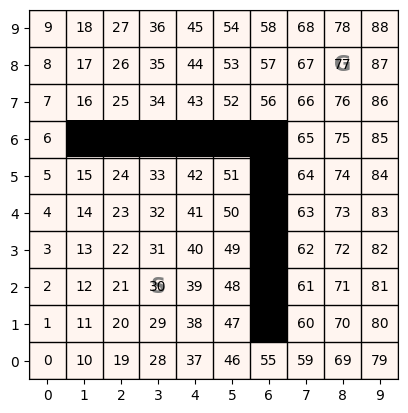

In [5]:
env.image()

In [7]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

sample_episode(env, max_len=1000)

[(30, 1, 0.0, 39),
 (39, 0, 0.0, 40),
 (40, 3, 0.0, 31),
 (31, 0, 0.0, 32),
 (32, 0, 0.0, 33),
 (33, 1, 0.0, 42),
 (42, 3, 0.0, 33),
 (33, 0, 0.0, 33),
 (33, 3, 0.0, 24),
 (24, 3, 0.0, 15),
 (15, 2, 0.0, 14),
 (14, 1, 0.0, 23),
 (23, 0, 0.0, 24),
 (24, 3, 0.0, 15),
 (15, 1, 0.0, 24),
 (24, 1, 0.0, 33),
 (33, 3, 0.0, 24),
 (24, 1, 0.0, 33),
 (33, 1, 0.0, 42),
 (42, 3, 0.0, 33),
 (33, 0, 0.0, 33),
 (33, 3, 0.0, 24),
 (24, 3, 0.0, 15),
 (15, 0, 0.0, 15),
 (15, 1, 0.0, 24),
 (24, 2, 0.0, 23),
 (23, 1, 0.0, 32),
 (32, 3, 0.0, 23),
 (23, 0, 0.0, 24),
 (24, 1, 0.0, 33),
 (33, 0, 0.0, 33),
 (33, 1, 0.0, 42),
 (42, 0, 0.0, 42),
 (42, 3, 0.0, 33),
 (33, 1, 0.0, 42),
 (42, 1, 0.0, 51),
 (51, 2, 0.0, 50),
 (50, 3, 0.0, 41),
 (41, 0, 0.0, 42),
 (42, 2, 0.0, 41),
 (41, 2, 0.0, 40),
 (40, 1, 0.0, 49),
 (49, 3, 0.0, 40),
 (40, 2, 0.0, 39),
 (39, 0, 0.0, 40),
 (40, 2, 0.0, 39),
 (39, 1, 0.0, 48),
 (48, 1, 0.0, 48),
 (48, 0, 0.0, 49),
 (49, 1, 0.0, 49),
 (49, 1, 0.0, 49),
 (49, 2, 0.0, 48),
 (48, 1, 0.0

## Define Linear State Features

In [8]:
from gym_classics.algorithms.linear_approximation import semi_gradient_Sarsa, state_features  

In [9]:
# overwrite state_features for the semi-gradient Sarsa implementation in gym_classics
def state_features(s):
    coord = env.decode(s)
    return np.concatenate([np.array([1]), np.array(coord)])

gym_classics.algorithms.linear_approximation.state_features = state_features

In [10]:
from gym_classics.algorithms.linear_approximation import q_hat
from gym_classics.algorithms.policy import greedy_policy

# helper to visualize the learned policy and value function 
def plot_w(w, title=None):
    Q = np.array([[q_hat(s, a, w) for a in range(env.action_space.n)] for s in range(env.observation_space.n)])
    V = np.max(Q, axis=1)
    pol = np.argmax(Q, axis=1)
    env.image(V, policy=pol, title=title, clim=(-1,1))
    
    return Q, V, pol

Learn weights.

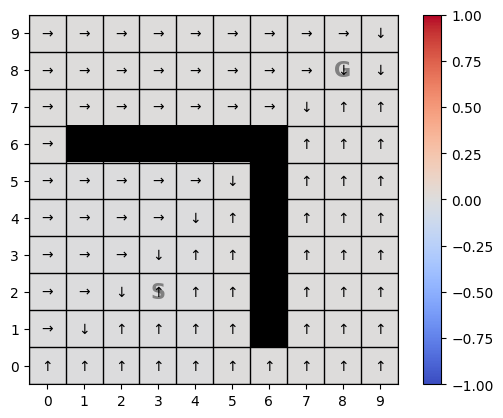

In [11]:
w = semi_gradient_Sarsa(env, n=1000, epsilon=0.1, alpha=0.001, gamma=.9, max_episode_length=1000, verbose=False)
Q, V, pol = plot_w(w)

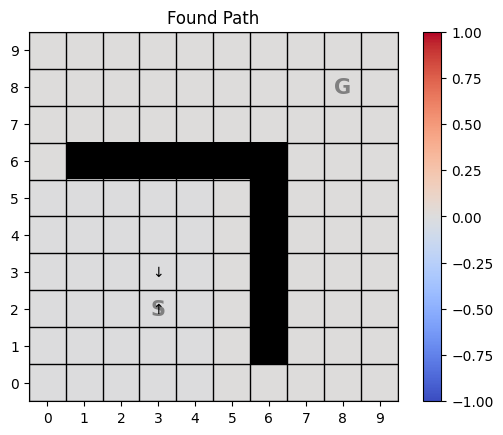

In [12]:
path = sample_episode(env, policy=pol, max_len=100)
env.image(V, policy=pol, episode=path, title='Found Path', clim=(-1,1))

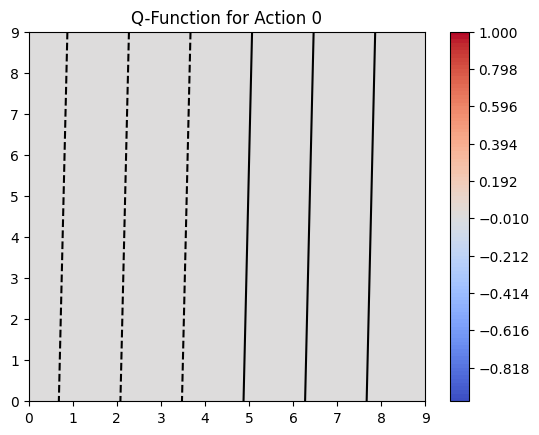

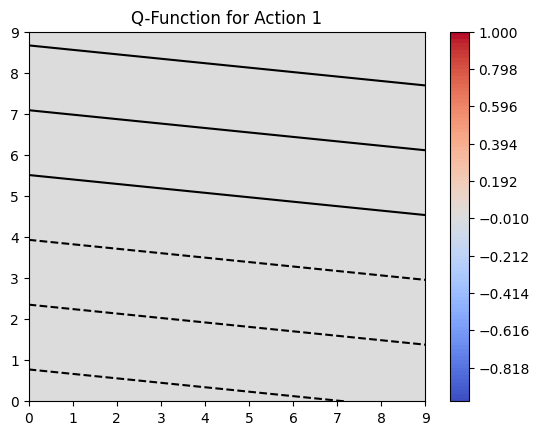

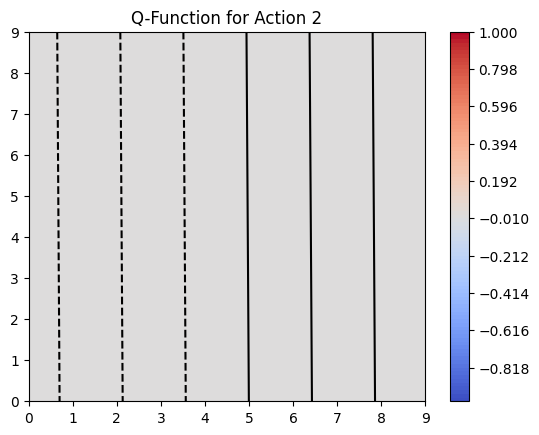

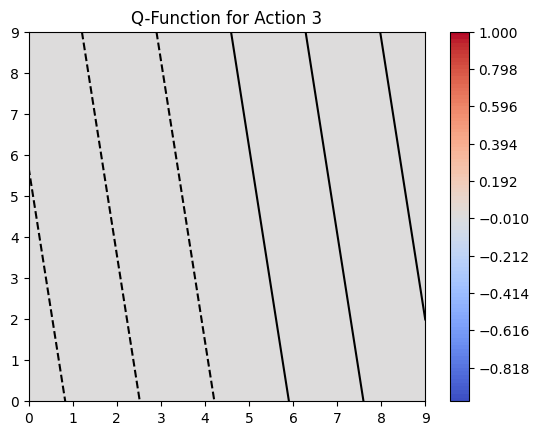

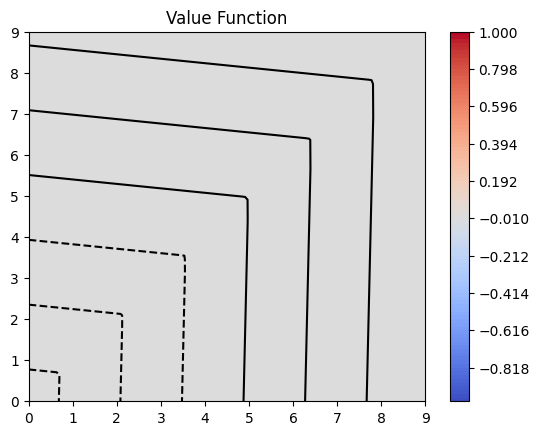

In [13]:
from matplotlib import pyplot as plt

dim = (9,9)

def active_weights(a):
    return [0] + list(range(a*2+1, a*2+2+1))

def q_hat_grid(x, y, a, w):
    return np.dot(w[active_weights(a)], [1, x, y])

x = np.linspace(0, dim[0], 100)
y = np.linspace(0, dim[1], 100)
X, Y = np.meshgrid(x, y)

# plot the Q-function for each action
for a in range(env.action_space.n):
    Z = np.array([q_hat_grid(x, y, a, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
    plt.contourf(X, Y, Z, cmap='coolwarm', levels=np.linspace(-1, 1, 100))
    plt.colorbar()
    plt.title(f'Q-Function for Action {a}')
    plt.contour(X, Y, Z, colors='black') # Contour lines
    plt.show()
    
# plot the value function
Z = np.array([np.max([q_hat_grid(x, y, a, w) for a in range(env.action_space.n)]) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
plt.contourf(X, Y, Z, cmap='coolwarm', levels=np.linspace(-1, 1, 100))
plt.colorbar()
plt.title('Value Function')
plt.contour(X, Y, Z, colors='black') # Contour lines
plt.show()


It is very unlikely that linear approximation works well for this problem! The agent will get stuck! We need to represent the states differently.


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)